# Personal Loan Acceptance Prediction

Objective: Predict which customers are likely to accept a personal loan offer.


Target Column: y

yes = accepted loan
no = did not accept

In [34]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusionmatrixDisplay

ImportError: cannot import name 'confusionmatrixDisplay' from 'sklearn.metrics' (C:\Users\hinaa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\__init__.py)

In [2]:
#Load the Dataset
# with sep=';' argument to define a semicolon as the delimiter (separator) between data fields in a CSV file 

df = pd.read_csv("bank-full.csv", sep=';')

In [3]:
#Understand the dataset
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


Columns names:<br>
   Input Variables:
   ##### bank client data:
   1 - age (numeric) <br>
   2 - job : type of job (categorical: "admin.","unknown","unemployed","management","housemaid","entrepreneur","student",
                                       "blue-collar","self-employed","retired","technician","services") <br>
   3 - marital : marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or widowed)<br>
   4 - education (categorical: "unknown","secondary","primary","tertiary")<br>
   5 - default: has credit in default? (binary: "yes","no")<br>
   6 - balance: average yearly balance, in euros (numeric) <br>
   7 - housing: has housing loan? (binary: "yes","no")<br>
   8 - loan: has personal loan? (binary: "yes","no") <br>
   ##### related with the last contact of the current campaign:
   9 - contact: contact communication type (categorical: "unknown","telephone","cellular") <br>
  10 - day: last contact day of the month (numeric) <br>
  11 - month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")<br>
  12 - duration: last contact duration, in seconds (numeric)<br>
   ##### other attributes:
  13 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)<br>
  14 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted)<br>
  15 - previous: number of contacts performed before this campaign and for this client (numeric)<br>
  16 - poutcome: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")<br>

  Output variable (desired target):<br>
  17 - y - has the client subscribed a term deposit? (binary: "yes","no")


In [4]:
print(df.shape)
print(df.info())

(45211, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB
None


### Basic Data Exploration

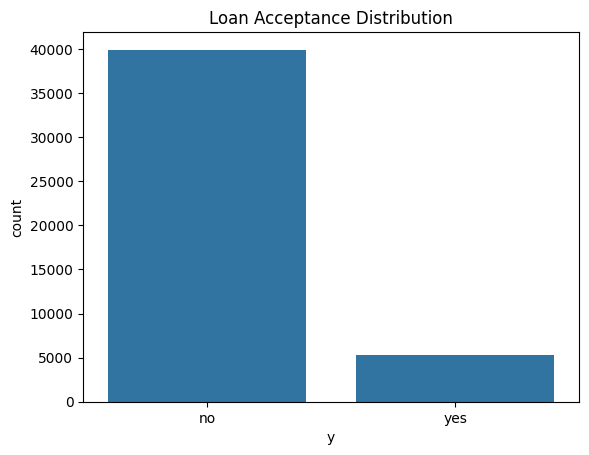

In [5]:
#Target Variable Distribution
sns.countplot(x='y', data=df)
plt.title("Loan Acceptance Distribution")
plt.show()

The loan acceptance distribution indicates that most customers declined the personal loan offer, while only a small proportion accepted. <br>
Approx ratio:
40000 / 5000 ≈8:1 <br>
So for every 8 customers who reject, only 1 accepts.
<br>
This creates a class imbalance problem that should be addressed during model training to improve prediction performance.

#### Exploring Important Features such as age, job, and marital status.

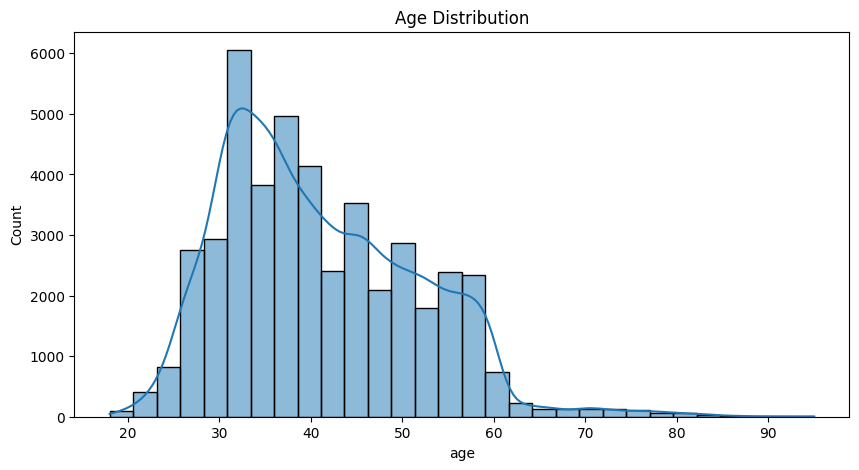

In [7]:
#Age Distribution
plt.figure(figsize=(10,5))
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

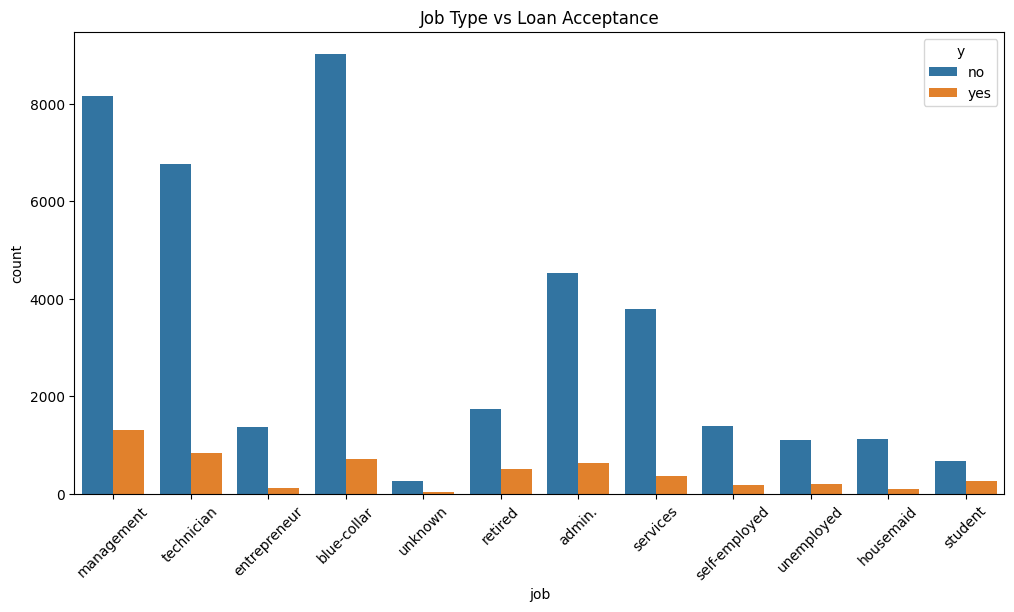

In [8]:
#Job Category vs Loan Acceptance
plt.figure(figsize=(12,6))
sns.countplot(x='job', hue='y', data=df)
plt.xticks(rotation=45)
plt.title("Job Type vs Loan Acceptance")
plt.show()

Management Customers Accepted More Loans (highest orange bars).
<br>
Management professionals may have:
<br>
Higher income<br>
Better credit profile<br>
Greater financial confidence<br>
Strong target segment for future campaigns.

Technicians Also Respond Well,
Second strong customer group.
<br>
Good secondary target audience.

Blue-Collar Has Many Customers But Lower Acceptance Rate<br>
Blue-collar has the highest total customers but orange bar is relatively smaller compared to blue.<br>
Large audience, but lower conversion efficiency.

Students Have Good Potential<br>
Even though student count is low, orange bar is noticeable relative to total.
Students may be interested in personal loans for education/living needs.
<br>

Housemaid / Unknown Jobs Low Acceptance<br>

Very low orange bars.<br>
Lower priority for marketing campaigns.

In [11]:
#Using Acceptance rate to better quantify the percentage of Loan accepted/rejected by Job type:

acceptance_rate = pd.crosstab(df['job'], df['y'], normalize='index') * 100
print(acceptance_rate)

y                     no        yes
job                                
admin.         87.797331  12.202669
blue-collar    92.725031   7.274969
entrepreneur   91.728312   8.271688
housemaid      91.209677   8.790323
management     86.244449  13.755551
retired        77.208481  22.791519
self-employed  88.157061  11.842939
services       91.116996   8.883004
student        71.321962  28.678038
technician     88.943004  11.056996
unemployed     84.497314  15.502686
unknown        88.194444  11.805556


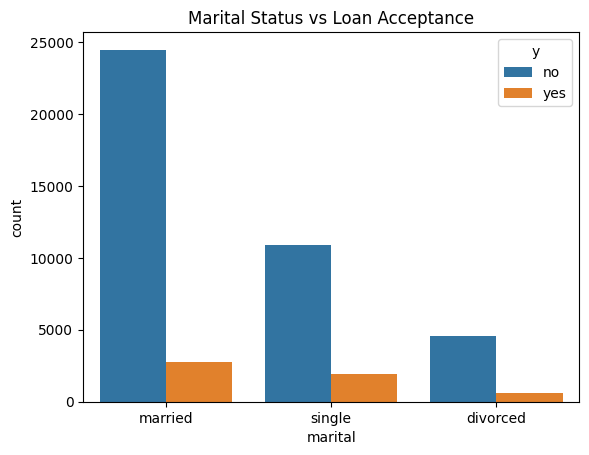

In [12]:
#Marital Status vs Loan Acceptance
sns.countplot(x='marital', hue='y', data=df)
plt.title("Marital Status vs Loan Acceptance")
plt.show()

In [13]:
#Convert Categorical Data
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

### Split Features & Target

In [19]:
X = df.drop('y', axis=1)
y = df['y']

In [20]:
#Train/Test split:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [21]:
#Scale features (needed for Logistic Regression)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

### Train Logistic Regression Model

In [22]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_sc, y_train)
lr_preds = lr.predict(X_test_sc)
lr_proba = lr.predict_proba(X_test_sc)[:, 1]

### Train Decision Tree Model

In [23]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

### Evaluate both Models

In [29]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.8848833351763795
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      7952
           1       0.56      0.20      0.30      1091

    accuracy                           0.88      9043
   macro avg       0.73      0.59      0.62      9043
weighted avg       0.86      0.88      0.86      9043



The model achieves a solid 88.5% overall accuracy, but that number is misleading. It performs very well on customers who reject the loan (class 0) with a recall of 98%, but struggles significantly on customers who accept it (class 1), only catching 20% of actual acceptors

In [38]:
print(confusion_matrix(y_test, y_pred_lr))

[[7779  173]
 [ 868  223]]


In [40]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.8935087913303107
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      7952
           1       0.59      0.40      0.48      1091

    accuracy                           0.89      9043
   macro avg       0.75      0.68      0.71      9043
weighted avg       0.88      0.89      0.88      9043



The Decision Tree shows a noticeable improvement over Logistic Regression, particularly for class 1.
Recall for acceptors jumps from 20% to 40%, and the F1-score improves from 0.30 to 0.48, meaning the model is now catching twice as many actual loan acceptors.
with overall accuracy is slightly higher at 89.3%,

In [41]:
print(confusion_matrix(y_test, y_pred_dt))

[[7644  308]
 [ 655  436]]


#### Feature Importance (Decision Tree)

In [27]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt.feature_importances_
}).sort_values(by='Importance', ascending=False)

importance

,Feature,Importance
11,duration,0.578134
15,poutcome,0.144215
10,month,0.113463
0,age,0.065036
13,pdays,0.057855
8,contact,0.023506
9,day,0.006439
6,housing,0.003712
12,campaign,0.003335
5,balance,0.002783


The Decision Tree model found that call duration was the most influential predictor of loan acceptance, followed by previous campaign outcome and month of contact. This suggests that customer engagement level, campaign timing, and prior responses strongly influence loan conversion.

##### More Insights

In [43]:
df['age_group'] = pd.cut(df['age'],
                         bins=[18,30,40,50,60,100],
                         labels=['18-30','31-40','41-50','51-60','60+'])

print(pd.crosstab(df['age_group'], df['y'], normalize='index')*100)

y                  0          1
age_group                      
18-30      83.784554  16.215446
31-40      89.755187  10.244813
41-50      90.933357   9.066643
51-60      89.946696  10.053304
60+        57.744108  42.255892


Which Age group accepts more?
<br>
The 60+ age group stands out from the rest, with a 42.3% acceptance rate, they are far more likely to accept the loan compared to every other group.
The middle-aged groups (31–50) are the hardest to convert, sitting at just 9–10% acceptance rate. 
Interestingly, younger customers (18–30) are more open than middle-aged ones at 16.2%, suggesting age has a non-linear relationship with loan acceptance rather than a simple increasing or decreasing trend.

### Which Model is Better?

In [46]:
print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("Decision Tree:", accuracy_score(y_test, y_pred_dt))

Logistic Regression: 0.8848833351763795
Decision Tree: 0.8935087913303107


The Decision Tree model achieved the highest accuracy of 89.35%, slightly outperforming Logistic Regression at 88.49%. Therefore, the Decision Tree was selected as the better predictive model based on accuracy.

### Conclusion
This project built a prediction model to identify customers likely to accept a personal loan offer. Between the two models tested, the Decision Tree slightly outperformed Logistic Regression with 89.35% accuracy vs 88.49%.
Key predictors included call duration, previous campaign outcome, and contact timing: suggesting that how and when you reach a customer matters as much as who they are. Exploratory analysis pointed to management, technician, and admin workers as more likely acceptors.
The main limitation was class imbalance, since most customers reject the offer, the model is better at predicting "no" than "yes." <br>